In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import matplotlib.lines as mlines

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.stats.multitest as smm

from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib import colors
import matplotlib.ticker as ticker

In [2]:
# Read in clustering results
cells = pd.read_csv('../data/t_cell_panel_clustering_results_patient_updated.csv', index_col=0)

#Delete spare progression sample (there was a second later measurement which was associated with progression)
#Delete sample 61290 006 as the patient went off trial due to participant preference
cells = cells.loc[cells['FlowSOM_metacluster_V1'] != 'P02_SPD_T_Cell_Panel',:]
cells = cells.loc[~cells['FlowSOM_metacluster_V1'].str.contains('P26'),:]
cells['FlowSOM_metacluster_V1'] = cells['FlowSOM_metacluster_V1'].str.replace('P02_SPD_2_T_Cell_Panel', 'P02_SPD_T_Cell_Panel')

# Delete the following samples as they have only a single measurement
cells = cells.loc[~cells['FlowSOM_metacluster_V1'].str.contains('P27'),:]
cells = cells.loc[~cells['FlowSOM_metacluster_V1'].str.contains('P15'),:]
cells.columns = cells.columns.str.replace('FlowSOM_metacluster_', '')
cells.columns = cells.columns.str.replace('V1', 'FileName')
cells

,FileName,1,10,11,12,13,14,15,16,17,...,37,38,39,4,40,5,6,7,8,9
0,P08_C1_D8_T_Cell_Panel,0,7662,993,2832,474,754,12,74,270,...,39,296,3235,3511,186,376,2504,904,385,283
1,P08_C7_D1_T_Cell_Panel,0,3073,106,1145,155,329,3,15,56,...,3,26,457,528,20,133,444,261,58,137
2,P08_C7_D22_T_Cell_Panel,0,3915,3,506,412,31,1,0,2,...,9,16,309,270,17,34,21,10,2,13
3,P08_SPD_T_Cell_Panel,0,4298,7,485,378,50,2,1,1,...,5,27,443,563,17,35,33,19,4,29
4,P24_C1_D1_T_Cell_Panel,0,6951,10,2831,565,84,43,0,2,...,3928,3298,273,220,192,63,803,57,73,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,Control_4_T_Cell_Panel,23800,50810,156,11888,1765,1949,1540,79,72,...,20055,5956,3533,13099,11237,146,477,128,5861,206
114,Control_12_T_Cell_Panel,0,7689,160,474,105,16,20,4,12,...,54,190,696,2014,28,73,902,15,30,16
115,Control_11_T_Cell_Panel,0,7770,202,454,91,17,23,10,11,...,8,47,732,2075,26,62,506,14,67,27
116,Control_3_T_Cell_Panel,2911,4251,0,1580,111,3,13,0,1,...,75,693,227,35674,75,45,1322,25,273,8


In [3]:
# Read in a table which describes the clustering results
cell_type = pd.read_csv('../data/t_cell_clsuters_2025_05_20.csv', index_col= 0)
cell_type_dict = dict(zip(cell_type['cluster'], cell_type['cell_type']))
cell_type_dict

{4: 'B cell',
 23: 'Cytokine NK Cell',
 24: 'Cytotoxic NK Cell',
 28: 'Cytotoxic NK Cell',
 33: 'Cytotoxic NK Cell',
 34: 'Cytotoxic NK Cell',
 35: 'Cytotoxic NK Cell',
 14: 'Plasma cell',
 10: 'CD4_T_cell',
 13: 'Treg',
 20: 'Treg',
 39: 'Cytotoxic_CD4',
 40: 'Cytotoxic_CD4',
 5: 'CD56_Myeloid',
 6: 'CD56_Myeloid',
 12: 'CD8_T_cell',
 27: 'CD8_T_cell',
 30: 'Cytotoxic CD56+ CD8 T cell',
 31: 'CD8_T_cell',
 32: 'Cytotoxic CD8',
 36: 'Cytotoxic CD8',
 38: 'Cytotoxic CD8',
 1: 'Monocytes',
 2: 'Monocytes',
 15: 'Monocytes',
 3: 'HSPCs',
 8: 'Immature myeloid',
 7: 'Neutrophils',
 9: 'Neutrophils',
 11: 'Neutrophils',
 16: 'Neutrophils',
 17: 'Neutrophils',
 21: 'Cytokine NK Cell',
 22: 'Cytotoxic NK Cell',
 29: 'Cytotoxic NK Cell',
 37: 'Cytotoxic NK Cell',
 18: 'CD56+ CD8 T cell',
 19: 'Cytotoxic CD8',
 25: 'Cytotoxic CD8',
 26: 'Cytotoxic CD56+ CD8 T cell'}

In [4]:
# Write a dictionary of cell types to cluster numbers
cell_dict = {}
for key, value in cell_type_dict.items():
    if value in cell_dict:
        cell_dict[value].append(str(key))
    else:
        cell_dict[value] = [str(key)]

In [5]:
# Sum together the columns which belong to specific cell types and th
for new_col, cols_to_sum in cell_dict.items():
    cells[new_col] = cells[cols_to_sum].sum(axis=1)
to_drop = [str(i +1) for i in range(40)]

# Delete the cluster numbers 
cells = cells.loc[:, ~cells.columns.isin(to_drop)]

del to_drop 

In [6]:
cells

,FileName,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,Cytotoxic CD56+ CD8 T cell,Cytotoxic CD8,Monocytes,HSPCs,Immature myeloid,Neutrophils,CD56+ CD8 T cell
0,P08_C1_D8_T_Cell_Panel,3511,1163,17029,754,7662,883,3421,2880,3273,1363,9061,9737,29051,385,2524,697
1,P08_C7_D1_T_Cell_Panel,528,213,2602,329,3073,347,477,577,1228,301,1440,1288,5517,58,575,282
2,P08_C7_D22_T_Cell_Panel,270,179,1900,31,3915,661,326,55,545,144,817,60,839,2,28,57
3,P08_SPD_T_Cell_Panel,563,186,2731,50,4298,835,460,68,578,236,1324,217,1400,4,57,66
4,P24_C1_D1_T_Cell_Panel,220,1483,4540,84,6951,760,465,866,2908,146,9210,2214,5246,73,79,43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,Control_4_T_Cell_Panel,13099,4719,21288,1949,50810,2642,14770,623,12759,4143,13871,47778,22280,5861,641,2887
114,Control_12_T_Cell_Panel,2014,102,2094,16,7689,347,724,975,550,615,4108,1467,1280,30,207,95
115,Control_11_T_Cell_Panel,2075,81,2119,17,7770,305,758,568,526,756,3979,1375,1586,67,264,67
116,Control_3_T_Cell_Panel,35674,120,188,3,4251,196,302,1367,1636,1804,2864,43451,3175,273,34,829


In [7]:
# Calculate the number of total cells acquired
cells['total_num'] = cells.loc[:, 'B cell':'CD56+ CD8 T cell'].sum(axis=1)
cells


/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/3469287034.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells['total_num'] = cells.loc[:, 'B cell':'CD56+ CD8 T cell'].sum(axis=1)


,FileName,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,Cytotoxic CD56+ CD8 T cell,Cytotoxic CD8,Monocytes,HSPCs,Immature myeloid,Neutrophils,CD56+ CD8 T cell,total_num
0,P08_C1_D8_T_Cell_Panel,3511,1163,17029,754,7662,883,3421,2880,3273,1363,9061,9737,29051,385,2524,697,93394
1,P08_C7_D1_T_Cell_Panel,528,213,2602,329,3073,347,477,577,1228,301,1440,1288,5517,58,575,282,18835
2,P08_C7_D22_T_Cell_Panel,270,179,1900,31,3915,661,326,55,545,144,817,60,839,2,28,57,9829
3,P08_SPD_T_Cell_Panel,563,186,2731,50,4298,835,460,68,578,236,1324,217,1400,4,57,66,13073
4,P24_C1_D1_T_Cell_Panel,220,1483,4540,84,6951,760,465,866,2908,146,9210,2214,5246,73,79,43,35288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,Control_4_T_Cell_Panel,13099,4719,21288,1949,50810,2642,14770,623,12759,4143,13871,47778,22280,5861,641,2887,220120
114,Control_12_T_Cell_Panel,2014,102,2094,16,7689,347,724,975,550,615,4108,1467,1280,30,207,95,22313
115,Control_11_T_Cell_Panel,2075,81,2119,17,7770,305,758,568,526,756,3979,1375,1586,67,264,67,22313
116,Control_3_T_Cell_Panel,35674,120,188,3,4251,196,302,1367,1636,1804,2864,43451,3175,273,34,829,96167


In [8]:
filename_dict = {}
for i in cells['FileName']:
    if i.startswith('P'):
        filename_dict[i] = i.split('_')[0]
    elif i.startswith('Control'):
        filename_dict[i] = i.split('_')[0] + '_' + i.split('_')[1]

cells.loc[:, 'pid'] = cells['FileName'].map(filename_dict)

timepoint_dict = {}
for i in cells['FileName']:
    if i.startswith('P'):
        x = i.replace('_T_Cell_Panel', '')
        x = '_'.join(i.replace('_T_Cell_Panel', '').split('_')[1:])
        timepoint_dict[i] = x
    elif 'Control' in i:
        timepoint_dict[i] = 'Control'

cells.loc[:, 'timepoint'] = cells['FileName'].map(timepoint_dict)

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/893778424.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells.loc[:, 'pid'] = cells['FileName'].map(filename_dict)
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/893778424.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells.loc[:, 'timepoint'] = cells['FileName'].map(timepoint_dict)


In [9]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', sheet_name = 'Sheet1', nrows=40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as 
# diagnosis and clinical outcomes

diagnosis_dx = {x: y for x, y in zip(patient_info['PID'], patient_info['Diagnosis'])}

outcome_C6_dx = {x: y for x, y in zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid'])}

outcome_C12_dx = {x: y for x, y in zip(patient_info['PID'], patient_info['Outcome_C12_CC486'])}



In [10]:
# Use the dictionaries to add clinical outcomes to the dataframe
cells['diagnosis'] = cells['pid'].map(diagnosis_dx)
cells['outcome_6'] = cells['pid'].map(outcome_C6_dx)
cells['outcome_12'] = cells['pid'].map(outcome_C12_dx)
cells

pid_timepoint = [x + '_' + y.replace('_', '') if 'P' in x else x for x, y in zip(cells['pid'], cells['timepoint'])]

cells['pid_timepoint'] = pid_timepoint
cells['pid_timepoint'] = cells['pid_timepoint'].astype(str)

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/3701504738.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells['diagnosis'] = cells['pid'].map(diagnosis_dx)
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/3701504738.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells['outcome_6'] = cells['pid'].map(outcome_C6_dx)
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/3701504738.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

In [11]:
cells

,FileName,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,...,Immature myeloid,Neutrophils,CD56+ CD8 T cell,total_num,pid,timepoint,diagnosis,outcome_6,outcome_12,pid_timepoint
0,P08_C1_D8_T_Cell_Panel,3511,1163,17029,754,7662,883,3421,2880,3273,...,385,2524,697,93394,P08,C1_D8,MDS,non-responder_2,non-responder_2,P08_C1D8
1,P08_C7_D1_T_Cell_Panel,528,213,2602,329,3073,347,477,577,1228,...,58,575,282,18835,P08,C7_D1,MDS,non-responder_2,non-responder_2,P08_C7D1
2,P08_C7_D22_T_Cell_Panel,270,179,1900,31,3915,661,326,55,545,...,2,28,57,9829,P08,C7_D22,MDS,non-responder_2,non-responder_2,P08_C7D22
3,P08_SPD_T_Cell_Panel,563,186,2731,50,4298,835,460,68,578,...,4,57,66,13073,P08,SPD,MDS,non-responder_2,non-responder_2,P08_SPD
4,P24_C1_D1_T_Cell_Panel,220,1483,4540,84,6951,760,465,866,2908,...,73,79,43,35288,P24,C1_D1,AML,non-responder_2,NaN,P24_C1D1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,Control_4_T_Cell_Panel,13099,4719,21288,1949,50810,2642,14770,623,12759,...,5861,641,2887,220120,Control_4,Control,NaN,NaN,NaN,Control_4
114,Control_12_T_Cell_Panel,2014,102,2094,16,7689,347,724,975,550,...,30,207,95,22313,Control_12,Control,NaN,NaN,NaN,Control_12
115,Control_11_T_Cell_Panel,2075,81,2119,17,7770,305,758,568,526,...,67,264,67,22313,Control_11,Control,NaN,NaN,NaN,Control_11
116,Control_3_T_Cell_Panel,35674,120,188,3,4251,196,302,1367,1636,...,273,34,829,96167,Control_3,Control,NaN,NaN,NaN,Control_3


In [12]:
# Read in data from Julie. This dataframe contains the patient outcomes and time when a sample was collected 
timepoints = pd.read_excel('../data/MS_flow_outcome_dx_clean_updatedJan24_patient_updated.xlsx')
timepoints['PID_Timepoint'] = timepoints['PID'].astype(str) + '_' + timepoints['Cycle_day']
to_keep = ['Cycle_day', 'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint']
timepoints = timepoints.loc[:,timepoints.columns.isin(to_keep)]
timepoints.head()
cells1 = pd.merge(cells, timepoints, left_on='pid_timepoint', right_on= 'PID_Timepoint', how = 'left')

# # Update the clinical outcomes and diagnosis columns to reflect that there are healthy samples in the sample set
diagnosis = ['Control' if 'Control' in x else y for x, y in zip(cells['pid'], cells['diagnosis'])]

outcome_6 = ['Control' if 'Control' in x else y for x, y in zip(cells['pid'], cells['outcome_6'])]

outcome_12 = ['Control' if 'Control' in x else y for x, y in zip(cells['pid'], cells['outcome_12'])]
        
cells1['diagnosis'] = diagnosis
cells1['outcome_6'] = outcome_6
cells1['outcome_12'] = outcome_12


In [13]:
cells1

,FileName,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,...,pid,timepoint,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint
0,P08_C1_D8_T_Cell_Panel,3511,1163,17029,754,7662,883,3421,2880,3273,...,P08,C1_D8,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8
1,P08_C7_D1_T_Cell_Panel,528,213,2602,329,3073,347,477,577,1228,...,P08,C7_D1,MDS,non-responder_2,non-responder_2,P08_C7D1,C7D1,217.0,243.0,P08_C7D1
2,P08_C7_D22_T_Cell_Panel,270,179,1900,31,3915,661,326,55,545,...,P08,C7_D22,MDS,non-responder_2,non-responder_2,P08_C7D22,C7D22,238.0,264.0,P08_C7D22
3,P08_SPD_T_Cell_Panel,563,186,2731,50,4298,835,460,68,578,...,P08,SPD,MDS,non-responder_2,non-responder_2,P08_SPD,NaN,NaN,NaN,NaN
4,P24_C1_D1_T_Cell_Panel,220,1483,4540,84,6951,760,465,866,2908,...,P24,C1_D1,AML,non-responder_2,NaN,P24_C1D1,C1D1,0.0,21.0,P24_C1D1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,Control_4_T_Cell_Panel,13099,4719,21288,1949,50810,2642,14770,623,12759,...,Control_4,Control,Control,Control,Control,Control_4,NaN,NaN,NaN,NaN
109,Control_12_T_Cell_Panel,2014,102,2094,16,7689,347,724,975,550,...,Control_12,Control,Control,Control,Control,Control_12,NaN,NaN,NaN,NaN
110,Control_11_T_Cell_Panel,2075,81,2119,17,7770,305,758,568,526,...,Control_11,Control,Control,Control,Control,Control_11,NaN,NaN,NaN,NaN
111,Control_3_T_Cell_Panel,35674,120,188,3,4251,196,302,1367,1636,...,Control_3,Control,Control,Control,Control,Control_3,NaN,NaN,NaN,NaN


In [14]:
# Add a column called best response to the df
best_response = ['responder' if x == 'responder_1' or y == 'responder_1' else 'non_responder' for x, y in zip(cells['outcome_6'], cells['outcome_12'])]
cells1['best_response'] = best_response
cells1.head()

,FileName,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,...,timepoint,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,best_response
0,P08_C1_D8_T_Cell_Panel,3511,1163,17029,754,7662,883,3421,2880,3273,...,C1_D8,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,non_responder
1,P08_C7_D1_T_Cell_Panel,528,213,2602,329,3073,347,477,577,1228,...,C7_D1,MDS,non-responder_2,non-responder_2,P08_C7D1,C7D1,217.0,243.0,P08_C7D1,non_responder
2,P08_C7_D22_T_Cell_Panel,270,179,1900,31,3915,661,326,55,545,...,C7_D22,MDS,non-responder_2,non-responder_2,P08_C7D22,C7D22,238.0,264.0,P08_C7D22,non_responder
3,P08_SPD_T_Cell_Panel,563,186,2731,50,4298,835,460,68,578,...,SPD,MDS,non-responder_2,non-responder_2,P08_SPD,NaN,NaN,NaN,NaN,non_responder
4,P24_C1_D1_T_Cell_Panel,220,1483,4540,84,6951,760,465,866,2908,...,C1_D1,AML,non-responder_2,NaN,P24_C1D1,C1D1,0.0,21.0,P24_C1D1,non_responder


In [15]:
# Create a list of patients which have a C7D22 but not a C7D1
patient_tp = []
for i in cells1['pid'].unique():
    a = cells1.loc[cells1['pid'] == i, :]
    if ('C7_D1' not in a['timepoint'].to_list()) and ('C7_D22' in a['timepoint'].to_list()):
        patient_tp.append(str(i) + '_C7D22')

In [16]:
# Filter the df for samples which were acquired at 'C1D1' or 'C7D1' or at C7D22 when they don't have a 
print(cells1.shape)
cells1 = cells1.loc[(cells1['Cycle_day'] ==  'C1D1') | (cells1['Cycle_day'] ==  'C7D1') | cells1['pid_timepoint'].isin(patient_tp), : ]
print(cells1.shape)

(113, 29)
(41, 29)


In [17]:
# Read in a dataframe which details the number of myeloid cells 
# so that I can figure out how to control for the number of stem and progenitor cells in each sample
hspc = pd.read_csv('../data/myeloid_panel_patient_metacluster_table_patient_updated.csv', index_col=0)
hspc['total_cells'] = hspc.loc[:, 'metacluster_1':'metacluster_9'].sum(axis = 1) #'metacluster_1''metacluster_2' metacluster_3 metacluster_9

hspc['hspc_lsc'] = hspc[['metacluster_1', 'metacluster_2', 'metacluster_3', 'metacluster_9']].sum(axis=1) # these coliumns are HSPC and aberrant
hspc['ratio_hspc_lsc'] = hspc.loc[:, 'hspc_lsc'].divide(hspc.loc[:, 'total_cells'], axis =0)
hspc['multiplication_factor'] = 1 - hspc.loc[:, 'ratio_hspc_lsc'] 
hspc['PID_Timepoint'] = hspc['FileNames'].str.replace('_Myeloid_Panel', '').str.replace('_C1_', '_C1').str.replace('_C7_', '_C7').str.replace('_C12_', '_C12')
hspc = hspc.loc[:, ['PID_Timepoint', 'multiplication_factor']]
hspc

,PID_Timepoint,multiplication_factor
0,P08_C1D8,0.852736
1,P08_C7D1,0.866397
2,P08_C7D22,0.954610
3,P08_SPD,0.945232
4,P24_C1D1,0.654679
...,...,...
113,Control_4,0.987427
114,Control_12,0.990564
115,Control_11,0.991135
116,Control_3,0.988056


In [18]:
hspc['PID_Timepoint'].unique()

array(['P08_C1D8', 'P08_C7D1', 'P08_C7D22', 'P08_SPD', 'P24_C1D1',
       'P24_C1D8', 'P24_C7D1', 'P19_C1D1', 'P19_C1D8', 'P19_C7D1',
       'P19_C7D22', 'P12_C12D29', 'P12_C1D1', 'P12_C1D8', 'P12_C7D22',
       'P04_C12D29', 'P04_C1D1', 'P04_C1D8', 'P04_C7D22', 'P03_C12D29',
       'P03_C1D1', 'P03_C1D8', 'P03_C7D1', 'P03_C7D22', 'P27_C1D1',
       'P38_C1D1', 'P38_C1D8', 'P06_C12D29', 'P06_C7D1', 'P06_C7D22',
       'P10_C12D29', 'P10_C1D1', 'P10_C1D8', 'P10_C7D1', 'P10_C7D22',
       'P16_C1D1', 'P16_C1D8', 'P16_C7D1', 'P16_C7D22', 'P14_C1D1',
       'P14_C1D8', 'P14_C7D22', 'P14_SPD', 'P05_C12D29', 'P05_C1D1',
       'P05_C1D8', 'P02_C1D1', 'P02_C1D8', 'P02_C7D1', 'P02_C7D22',
       'P02_SPD_2', 'P02_SPD', 'P01_C12D29', 'P01_C1D1', 'P01_C1D8',
       'P01_C7D1', 'P01_C7D22', 'P11_C12D29', 'P11_C1D1', 'P11_C1D8',
       'P11_C7D1', 'P11_C7D22', 'P28_C1D1', 'P28_C1D8', 'P07_C12D29',
       'P07_C1D1', 'P07_C1D8', 'P07_C7D1', 'P07_C7D22', 'P15_C1D8',
       'P20_C1D8', 'P20_C7D22', '

In [19]:
# Merge the two dataframes and then create a column called corrected cell number
cells1 = pd.merge(cells1, hspc, left_on = 'PID_Timepoint', right_on = 'PID_Timepoint')
cells1['corrected_cell_num'] = cells1['total_num'] * cells1['multiplication_factor']
cells1['corrected_cell_num'] = cells1['corrected_cell_num'].astype(int)

In [20]:
for x, y in enumerate(cells1.columns):
    print(x, y)

0 FileName
1 B cell
2 Cytokine NK Cell
3 Cytotoxic NK Cell
4 Plasma cell
5 CD4_T_cell
6 Treg
7 Cytotoxic_CD4
8 CD56_Myeloid
9 CD8_T_cell
10 Cytotoxic CD56+ CD8 T cell
11 Cytotoxic CD8
12 Monocytes
13 HSPCs
14 Immature myeloid
15 Neutrophils
16 CD56+ CD8 T cell
17 total_num
18 pid
19 timepoint
20 diagnosis
21 outcome_6
22 outcome_12
23 pid_timepoint
24 Cycle_day
25 Day_since_C1D1
26 Day_since_scr
27 PID_Timepoint
28 best_response
29 multiplication_factor
30 corrected_cell_num


In [21]:
cells1

,FileName,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,...,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,best_response,multiplication_factor,corrected_cell_num
0,P08_C7_D1_T_Cell_Panel,528,213,2602,329,3073,347,477,577,1228,...,non-responder_2,non-responder_2,P08_C7D1,C7D1,217.0,243.0,P08_C7D1,non_responder,0.866397,16318
1,P24_C1_D1_T_Cell_Panel,220,1483,4540,84,6951,760,465,866,2908,...,non-responder_2,NaN,P24_C1D1,C1D1,0.0,21.0,P24_C1D1,non_responder,0.654679,23102
2,P24_C7_D1_T_Cell_Panel,1988,1307,16809,730,40688,3015,1428,3998,25053,...,non-responder_2,NaN,P24_C7D1,C7D1,189.0,210.0,P24_C7D1,non_responder,0.785711,138683
3,P19_C1_D1_T_Cell_Panel,129,94,106,89,174,28,81,41446,527,...,responder_1,NaN,P19_C1D1,C1D1,0.0,25.0,P19_C1D1,responder,0.950551,99774
4,P19_C7_D1_T_Cell_Panel,1561,464,6823,212,3332,314,2170,339,5753,...,responder_1,NaN,P19_C7D1,C7D1,175.0,200.0,P19_C7D1,responder,0.985167,50412
5,P12_C1_D1_T_Cell_Panel,2116,871,5064,2035,16624,1269,1448,40785,6940,...,responder_1,responder_1,P12_C1D1,C1D1,0.0,56.0,P12_C1D1,responder,0.963834,364167
6,P12_C7_D22_T_Cell_Panel,2459,2079,38681,1000,24540,6393,12732,28210,13066,...,responder_1,responder_1,P12_C7D22,C7D22,193.0,249.0,P12_C7D22,responder,0.988136,364997
7,P04_C1_D1_T_Cell_Panel,1986,396,2843,119,7878,637,2146,715,6487,...,responder_1,non-responder_2,P04_C1D1,C1D1,0.0,34.0,P04_C1D1,responder,0.376767,30934
8,P04_C7_D22_T_Cell_Panel,1277,664,10043,1356,18685,2650,2129,13620,17632,...,responder_1,non-responder_2,P04_C7D22,C7D22,204.0,238.0,P04_C7D22,responder,0.958847,165492
9,P03_C1_D1_T_Cell_Panel,2902,4468,22464,107,8587,1397,831,247,8600,...,responder_1,responder_1,P03_C1D1,C1D1,0.0,27.0,P03_C1D1,responder,0.989123,126846


In [22]:
# Create a list called 'selected_columns' so that I can then perform the same mathematical operation
# on this entire list of columns

selected_columns = [col for col in cells1.columns[1:17]]
selected_columns = [x for x in selected_columns if x != 'HSPCs']

# For each column in 'selected_columns' delete the spare column
cells1['corrected_cell_num'] = cells1['corrected_cell_num'].astype(int)
cells1[selected_columns] = cells1[selected_columns].div(cells1['corrected_cell_num'], axis = 0) * 100

cells1['HSPCs'] = cells1['HSPCs'].div(cells1['total_num'], axis = 0) * 100

del selected_columns

In [23]:
cells1

,FileName,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,...,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,best_response,multiplication_factor,corrected_cell_num
0,P08_C7_D1_T_Cell_Panel,3.235691,1.305307,15.945582,2.016178,18.831965,2.126486,2.923152,3.535973,7.525432,...,non-responder_2,non-responder_2,P08_C7D1,C7D1,217.0,243.0,P08_C7D1,non_responder,0.866397,16318
1,P24_C1_D1_T_Cell_Panel,0.952299,6.419358,19.651978,0.363605,30.088304,3.289758,2.012813,3.748593,12.587655,...,non-responder_2,NaN,P24_C1D1,C1D1,0.0,21.0,P24_C1D1,non_responder,0.654679,23102
2,P24_C7_D1_T_Cell_Panel,1.433485,0.942437,12.120447,0.526380,29.338852,2.174023,1.029686,2.882834,18.064939,...,non-responder_2,NaN,P24_C7D1,C7D1,189.0,210.0,P24_C7D1,non_responder,0.785711,138683
3,P19_C1_D1_T_Cell_Panel,0.129292,0.094213,0.106240,0.089202,0.174394,0.028063,0.081183,41.539880,0.528194,...,responder_1,NaN,P19_C1D1,C1D1,0.0,25.0,P19_C1D1,responder,0.950551,99774
4,P19_C7_D1_T_Cell_Panel,3.096485,0.920416,13.534476,0.420535,6.609537,0.622868,4.304531,0.672459,11.411965,...,responder_1,NaN,P19_C7D1,C7D1,175.0,200.0,P19_C7D1,responder,0.985167,50412
5,P12_C1_D1_T_Cell_Panel,0.581052,0.239176,1.390571,0.558810,4.564939,0.348467,0.397620,11.199532,1.905719,...,responder_1,responder_1,P12_C1D1,C1D1,0.0,56.0,P12_C1D1,responder,0.963834,364167
6,P12_C7_D22_T_Cell_Panel,0.673704,0.569594,10.597621,0.273975,6.723343,1.751521,3.488248,7.728831,3.579755,...,responder_1,responder_1,P12_C7D22,C7D22,193.0,249.0,P12_C7D22,responder,0.988136,364997
7,P04_C1_D1_T_Cell_Panel,6.420120,1.280145,9.190535,0.384690,25.467124,2.059223,6.937350,2.311373,20.970453,...,responder_1,non-responder_2,P04_C1D1,C1D1,0.0,34.0,P04_C1D1,responder,0.376767,30934
8,P04_C7_D22_T_Cell_Panel,0.771639,0.401228,6.068571,0.819375,11.290576,1.601286,1.286467,8.230005,10.654291,...,responder_1,non-responder_2,P04_C7D22,C7D22,204.0,238.0,P04_C7D22,responder,0.958847,165492
9,P03_C1_D1_T_Cell_Panel,2.287814,3.522381,17.709664,0.084354,6.769626,1.101335,0.655125,0.194724,6.779875,...,responder_1,responder_1,P03_C1D1,C1D1,0.0,27.0,P03_C1D1,responder,0.989123,126846


In [24]:
# Replace empty strings in the dataframe and add another column as an integer so that 
# I can perfom some statistical analysis
cells1.columns = cells1.columns.str.replace(' ', '_')
cells1['time_point'] = ((cells1['Cycle_day'] == 'C7D1') | (cells1['Cycle_day'] == 'C7D22')).astype(int)

In [25]:
cells1.columns

Index(['FileName', 'B_cell', 'Cytokine_NK_Cell', 'Cytotoxic_NK_Cell',
       'Plasma_cell', 'CD4_T_cell', 'Treg', 'Cytotoxic_CD4', 'CD56_Myeloid',
       'CD8_T_cell', 'Cytotoxic_CD56+_CD8_T_cell', 'Cytotoxic_CD8',
       'Monocytes', 'HSPCs', 'Immature_myeloid', 'Neutrophils',
       'CD56+_CD8_T_cell', 'total_num', 'pid', 'timepoint', 'diagnosis',
       'outcome_6', 'outcome_12', 'pid_timepoint', 'Cycle_day',
       'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint', 'best_response',
       'multiplication_factor', 'corrected_cell_num', 'time_point'],
      dtype='object')

In [26]:
# Create a function to run the mixed-effects model for a single column
def run_mixed_model(df, column):
    model_data = df[['pid', 'time_point', column]].copy()
    model_data.columns = ['pid', 'time_point', 'value']
    
    # Fit a linear mixed-effects model
    model = smf.mixedlm('value ~ time_point', model_data, groups=model_data['pid'])
    result = model.fit()
    
    return result

In [27]:
# Run the analysis for each relevant column
r_results = {}
nr_results = {}
for i in cells1['best_response'].unique():
    a = cells1.loc[cells1['best_response'] == i, :]
    for column in a.columns[1:17]:  # Adjust the range as needed
        print(f"Analyzing {column}:")
        result = run_mixed_model(a, column)
        print(result.summary())
        print('\n')
        if i == 'responder':
            r_results[column] = result
        elif i == 'non_responder':
            nr_results[column] = result

Analyzing B_cell:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 12      Method:             REML    
No. Groups:       8       Scale:              0.5300  
Min. group size:  1       Log-Likelihood:     -25.6444
Max. group size:  2       Converged:          Yes     
Mean group size:  1.5                                 
------------------------------------------------------
             Coef.  Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------
Intercept     3.083    1.412 2.184 0.029  0.316  5.851
time_point    0.218    0.515 0.424 0.672 -0.791  1.227
Group Var    15.257   21.487                          



Analyzing Cytokine_NK_Cell:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 12      Method:             REML    
No. Groups:       8       Scale:              2.7327  
Min. group size:  1       Log-Like

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: value   
No. Observations:  12      Method:             REML    
No. Groups:        8       Scale:              20.4829 
Min. group size:   1       Log-Likelihood:     -38.4455
Max. group size:   2       Converged:          Yes     
Mean group size:   1.5                                 
-------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------
Intercept   11.890    4.135  2.876 0.004   3.786 19.994
time_point  -4.440    3.114 -1.425 0.154 -10.544  1.665
Group Var  110.508   24.701                            



Analyzing Monocytes:
         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: value   
No. Observations:  12      Method:             REML    
No. Groups:        8       Scale:              397.8926
Min. group size:   1       Log-Likelihood:

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 29      Method:             REML    
No. Groups:       16      Scale:              25.5099 
Min. group size:  1       Log-Likelihood:     -96.0121
Max. group size:  2       Converged:          Yes     
Mean group size:  1.8                                 
------------------------------------------------------
             Coef.  Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    11.533    2.273 5.075 0.000  7.079 15.987
time_point    3.142    1.946 1.615 0.106 -0.672  6.955
Group Var    50.996    6.892                          



Analyzing Plasma_cell:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 29      Method:             REML    
No. Groups:       16      Scale:              0.0692  
Min. group size:  1       Log-Likelihood:     -11.4614
Ma

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value    
No. Observations: 29      Method:             REML     
No. Groups:       16      Scale:              95.0840  
Min. group size:  1       Log-Likelihood:     -102.4742
Max. group size:  2       Converged:          Yes      
Mean group size:  1.8                                  
-------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------
Intercept    7.504    2.606  2.879 0.004   2.396 12.612
time_point  -3.676    3.717 -0.989 0.323 -10.960  3.608
Group Var    0.000    4.365                            



Analyzing CD8_T_cell:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 29      Method:             REML    
No. Groups:       16      Scale:              15.8085 
Min. group size:  1       Log-Likelihood:    

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [28]:
# Add the p-values to a dictionary
r_pval_dict = {}
nr_pval_dict = {}
for i in r_results:
    r_pval_dict[i] = r_results[i].pvalues[1]
for i in nr_results:
    nr_pval_dict[i] = nr_results[i].pvalues[1]
    


/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/911373739.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_pval_dict[i] = r_results[i].pvalues[1]
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/911373739.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_pval_dict[i] = r_results[i].pvalues[1]
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/911373739.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posit

In [29]:
# Update the p-values in each dictionary to account for multiple testing hypothesis
def correct_p_values(dict1, dict2):
    # Combine p-values from both dictionaries
    all_p_values = list(dict1.values()) + list(dict2.values())
    
    # Perform FDR correction
    rejected, corrected_p_values, _, _ = smm.multipletests(all_p_values, method='fdr_bh')
    
    # Split the corrected p-values back into two lists
    split_index = len(dict1)
    corrected_dict1 = corrected_p_values[:split_index]
    corrected_dict2 = corrected_p_values[split_index:]
    
    # Update the original dictionaries with corrected p-values
    for (key, _), corrected_p in zip(dict1.items(), corrected_dict1):
        dict1[key] = corrected_p
    
    for (key, _), corrected_p in zip(dict2.items(), corrected_dict2):
        dict2[key] = corrected_p
    
    return dict1, dict2

# Apply the correction
r_pval_dict1, nr_pval_dict1 = correct_p_values(r_pval_dict, nr_pval_dict)

# Print the results
print("Corrected dict1:", r_pval_dict1)
print("Corrected dict2:", nr_pval_dict1)


Corrected dict1: {'B_cell': 0.7193714616049003, 'Cytokine_NK_Cell': 0.27670548955154434, 'Cytotoxic_NK_Cell': 0.27670548955154434, 'Plasma_cell': 0.12153472943457959, 'CD4_T_cell': 0.12822217867835667, 'Treg': 0.12153472943457959, 'Cytotoxic_CD4': 0.7193714616049003, 'CD56_Myeloid': 0.5055806931816724, 'CD8_T_cell': 0.2088474908234018, 'Cytotoxic_CD56+_CD8_T_cell': 0.00018247127343351544, 'Cytotoxic_CD8': 0.2804776297079261, 'Monocytes': 4.4966303319388217e-13, 'HSPCs': 0.7193714616049003, 'Immature_myeloid': 0.0022578157275336213, 'Neutrophils': 0.00018247127343351544, 'CD56+_CD8_T_cell': 0.9212749140496024}
Corrected dict2: {'B_cell': 0.7193714616049003, 'Cytokine_NK_Cell': 0.5602455211569495, 'Cytotoxic_NK_Cell': 0.5710932020390588, 'Plasma_cell': 0.27670548955154434, 'CD4_T_cell': 0.7183875419426516, 'Treg': 0.7193714616049003, 'Cytotoxic_CD4': 0.2804776297079261, 'CD56_Myeloid': 0.27670548955154434, 'CD8_T_cell': 0.2804776297079261, 'Cytotoxic_CD56+_CD8_T_cell': 0.9212749140496024

In [30]:
import re

def text_to_int(text_obj):
    # Get the text content from the text object
    text_content = text_obj.get_text()
    
    # Replace Unicode minus sign (U+2212) with ASCII minus sign
    text_content = text_content.replace('\u2212', '-')
    
    # Remove any non-digit characters, but keep the minus sign at the beginning if present
    cleaned_text = re.sub(r'^-?\D*(-?\d+).*$', r'\1', text_content)
    cleaned_text = cleaned_text.replace("''", "")
    try:
        # Try to convert the cleaned string to an integer
        return int(cleaned_text)
    except ValueError:
        print(f"Could not convert '{text_content}' to an integer.")
        return None


In [31]:
def add_significance_stars(ax, x, y, p_value, is_responder, fontsize=8):
    # Map p-value thresholds to stars
    thresholds = [(0.0001, '****'), (0.001, '***'), (0.01, '**'), (0.05, '*')]
    
    stars = next((s for threshold, s in thresholds if p_value < threshold), None)
    if not stars:
        return
    
    y_limit = ax.get_ylim()[1]
    bar_width = 0.35
    offset = 5.08  # Distance between line and star center
    
    if is_responder:
        # For responders (top): line first, then stars above it
        line_y = y_limit * 0.80
        star_y = line_y + offset
    else:
        # For non-responders (bottom): line first, then stars below it
        line_y = y_limit * -0.80
        star_y = line_y - (offset * 2.5)
    
    # Add horizontal line
    color = 'black' #if is_responder else '#fe9003'
    ax.hlines(y=line_y, xmin=x - bar_width/2, xmax=x + bar_width/2, 
              colors=color, linewidth=0.8, linestyle='-')
    
    # Add the stars with centered alignment for symmetry
    ax.text(x, star_y, stars, ha='center', va='center', fontsize=fontsize)

In [32]:
# Read in a sheet which details the cluster, color of each cluster and order of the plotting
order = pd.read_excel('../data/t_cell_panel_cluster_color_and_order.xlsx')
order['Cluster'] = order['Cluster'].replace('Myeloid Progenitor', 'Immature_myeloid') # rename to match the columns in the dataframe
order = order.sort_values('Order')
order_dict = dict(zip(order['Cluster'].str.replace(' ', '_'), order['Order']))
color_dict = dict(zip(order['Cluster'], order['color']))


In [33]:
cells1['Cycle_day'] = cells1['Cycle_day'].str.replace('C7D22', 'C7D1')
cells1

,FileName,B_cell,Cytokine_NK_Cell,Cytotoxic_NK_Cell,Plasma_cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,...,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,best_response,multiplication_factor,corrected_cell_num,time_point
0,P08_C7_D1_T_Cell_Panel,3.235691,1.305307,15.945582,2.016178,18.831965,2.126486,2.923152,3.535973,7.525432,...,non-responder_2,P08_C7D1,C7D1,217.0,243.0,P08_C7D1,non_responder,0.866397,16318,1
1,P24_C1_D1_T_Cell_Panel,0.952299,6.419358,19.651978,0.363605,30.088304,3.289758,2.012813,3.748593,12.587655,...,NaN,P24_C1D1,C1D1,0.0,21.0,P24_C1D1,non_responder,0.654679,23102,0
2,P24_C7_D1_T_Cell_Panel,1.433485,0.942437,12.120447,0.526380,29.338852,2.174023,1.029686,2.882834,18.064939,...,NaN,P24_C7D1,C7D1,189.0,210.0,P24_C7D1,non_responder,0.785711,138683,1
3,P19_C1_D1_T_Cell_Panel,0.129292,0.094213,0.106240,0.089202,0.174394,0.028063,0.081183,41.539880,0.528194,...,NaN,P19_C1D1,C1D1,0.0,25.0,P19_C1D1,responder,0.950551,99774,0
4,P19_C7_D1_T_Cell_Panel,3.096485,0.920416,13.534476,0.420535,6.609537,0.622868,4.304531,0.672459,11.411965,...,NaN,P19_C7D1,C7D1,175.0,200.0,P19_C7D1,responder,0.985167,50412,1
5,P12_C1_D1_T_Cell_Panel,0.581052,0.239176,1.390571,0.558810,4.564939,0.348467,0.397620,11.199532,1.905719,...,responder_1,P12_C1D1,C1D1,0.0,56.0,P12_C1D1,responder,0.963834,364167,0
6,P12_C7_D22_T_Cell_Panel,0.673704,0.569594,10.597621,0.273975,6.723343,1.751521,3.488248,7.728831,3.579755,...,responder_1,P12_C7D22,C7D1,193.0,249.0,P12_C7D22,responder,0.988136,364997,1
7,P04_C1_D1_T_Cell_Panel,6.420120,1.280145,9.190535,0.384690,25.467124,2.059223,6.937350,2.311373,20.970453,...,non-responder_2,P04_C1D1,C1D1,0.0,34.0,P04_C1D1,responder,0.376767,30934,0
8,P04_C7_D22_T_Cell_Panel,0.771639,0.401228,6.068571,0.819375,11.290576,1.601286,1.286467,8.230005,10.654291,...,non-responder_2,P04_C7D22,C7D1,204.0,238.0,P04_C7D22,responder,0.958847,165492,1
9,P03_C1_D1_T_Cell_Panel,2.287814,3.522381,17.709664,0.084354,6.769626,1.101335,0.655125,0.194724,6.779875,...,responder_1,P03_C1D1,C1D1,0.0,27.0,P03_C1D1,responder,0.989123,126846,0


In [34]:
cells1['timepoint']

0      C7_D1
1      C1_D1
2      C7_D1
3      C1_D1
4      C7_D1
5      C1_D1
6     C7_D22
7      C1_D1
8     C7_D22
9      C1_D1
10     C7_D1
11     C1_D1
12     C7_D1
13     C1_D1
14     C7_D1
15     C1_D1
16     C7_D1
17     C1_D1
18    C7_D22
19     C1_D1
20     C1_D1
21     C7_D1
22     C1_D1
23     C7_D1
24     C1_D1
25     C7_D1
26     C1_D1
27     C1_D1
28     C7_D1
29    C7_D22
30     C1_D1
31     C7_D1
32     C1_D1
33     C7_D1
34     C1_D1
35     C7_D1
36     C1_D1
37     C1_D1
38     C7_D1
39     C1_D1
40     C7_D1
Name: timepoint, dtype: object

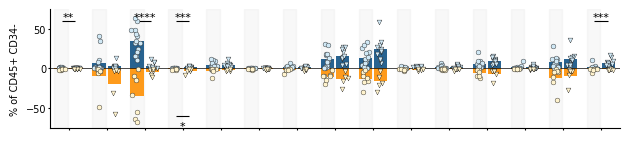

In [35]:
fig, ax = plt.subplots(figsize=(6.6 * (13/14), 1.25)) 
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

# Define colors for different times
colors = {'non_responder': '#fe9003', 'responder': '#115284'}

colors1 = {'non_responder': '#FFF3CD', 'responder':  '#D0E8F5'}

markers = {'C1_D1': 'o', 'C7_D1': 'v'}
#alphas = {'C1_D1': 0.5, 'C7_D1': 1.0}

# Define the categories and their positions on the x-axis
# Define the categories and their positions on the x-axis
#categories = list(order_dict.keys())
categories = [y for x, y in enumerate(order_dict.keys()) if x >= 1]
x_positions = np.arange(len(categories))

disease_colors = {
    'MDS': 'white',
    'AML': '#E377C2', 
    'CMML': '#17BECF',
}

# Set the width of each bar
bar_width = 0.35

mean_values = cells1.groupby(['best_response', 'timepoint'])[categories].mean()

time_offsets = {'C1_D1': -bar_width/2 - 0.025, 'C7_D1': bar_width/2 + 0.025}

y_max = cells1[categories].max().max() * 1.1
y_min = cells1[categories].max().max() * -1.1
ax.set_ylim(y_min, y_max)


# Plot bars for each outcome and time
for outcome in ['responder', 'non_responder']:
    multiplier = 1 if outcome == 'responder' else -1

    ax.bar(x_positions + time_offsets['C1_D1'], y_max * multiplier, bar_width,#65 * multiplier, bar_width,
           facecolor='lightgrey', edgecolor='lightgrey', alpha=0.15)#,
           #hatch='xxxxxx', linewidth=0.5, zorder=1)

    for time, offset in time_offsets.items():
        values = mean_values.loc[outcome, time]
        ax.bar(x_positions + offset, values * multiplier, bar_width,
               facecolor=colors[outcome], edgecolor=None,
               alpha=0.9, label=f'{outcome} - {time}')

        for i, category in enumerate(categories):
            subset = cells1[(cells1['best_response'] == outcome) & (cells1['timepoint'] == time)]
            x_jitter = np.random.normal(0, 0.05, size=len(subset))  # x jitter for vertical chart
            ax.scatter(x_positions[i] + offset + x_jitter,          # x = category position
                       subset[category] * multiplier,                # y = value
                       marker=markers[time],
                       facecolor= colors1[outcome],
                       edgecolor='black', linewidth=0.25,
                       alpha=1, s=12, zorder=3)

# Add a horizontal line to the graph
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)


# # Set labels and title
ax.tick_params(axis='both', labelsize=7, pad = 1, length = 1.5)    
ax.set_xticks(range(len(categories)))

# y_min, y_max = ax.get_ylim()
#ax.set_yticklabels([-75, -50, -25, 0, 25, 50, 75], fontsize=7)
#ax.set_ylim(-75, 75)
labels = [i.replace('_', ' ') for i in categories]
labels = [i.replace(' pos', '+') for i in labels]
labels = [i.replace(' neg', '-') for i in labels]
labels = [i.replace('Cytotoxic C', 'GzmB+ C') for i in labels]
labels = [i.replace('T cell', 'T') for i in labels]
ax.set_xticklabels([], rotation = 90, fontsize = 7)
ax.set_xlim(-0.5, 14.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('% of CD45+ CD34-', fontsize = 7)


# Add significance stars after setting the y-limits
for outcome in ['responder', 'non_responder']:
    for i, category in enumerate(categories):
        p_value = r_pval_dict1[category] if outcome == 'responder' else nr_pval_dict1[category]
        add_significance_stars(ax, x_positions[i], 1, p_value, outcome == 'responder')

fig.set_size_inches((6.6 * (13/14), 1.25))
fig.tight_layout(pad=0.1)
fig.savefig('../results/cell_types_graphs2.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_50933/589282028.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = yticklabels, fontsize = 7)


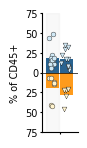

In [94]:

fig, ax = plt.subplots(figsize=(6.6 * (1.6/15), 1.25)) 

plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

# Define colors for different times
colors = {'non_responder': '#fe9003', 'responder': '#115284'}

colors1 = {'non_responder': '#FFF3CD', 'responder':  '#D0E8F5'}
markers = {'C1_D1': 'o', 'C7_D1': 'v'}

# Define the categories and their positions on the x-axis
categories = ['HSPCs']

x_positions = np.arange(len(categories))

# Set the width of each bar
bar_width = 0.35

mean_values = cells1.groupby(['best_response', 'timepoint'])[categories].mean()

y_max = cells1[categories].max().max() * 1.1
y_min = cells1[categories].max().max() * -1.1
ax.set_ylim(y_min, y_max)


# Plot bars for each outcome and time
for outcome in ['responder', 'non_responder']:
    multiplier = 1 if outcome == 'responder' else -1

    ax.bar(x_positions + time_offsets['C1_D1'], height = 75 * multiplier, width = bar_width,
           #y_max * multiplier, 
           facecolor='lightgrey', edgecolor='lightgrey', alpha=0.15)#,
           #hatch='xxxxxx', linewidth=0.5, zorder=1)

    for time, offset in time_offsets.items():
        values = mean_values.loc[outcome, time]
        ax.bar(x_positions + offset, values * multiplier, bar_width,
               facecolor=colors[outcome], edgecolor=None,
               alpha=0.9, label=f'{outcome} - {time}')

        for i, category in enumerate(categories):
            subset = cells1[(cells1['best_response'] == outcome) & (cells1['timepoint'] == time)]
            x_jitter = np.random.normal(0, 0.05, size=len(subset))  # x jitter for vertical chart
            ax.scatter(x_positions[i] + offset + x_jitter,          # x = category position
                       subset[category] * multiplier,                # y = value
                       marker=markers[time],
                       facecolor= colors1[outcome],
                       edgecolor='black', linewidth=0.25,
                       alpha=1, s=12, zorder=3)

# Add a horizontal line to the graph
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)


# # Set labels and title
ax.set_ylim(-75, 75)
ax.tick_params(axis='both', labelsize=7, pad = 1, length = 1.5)    
ax.set_xticks(range(len(categories)))
yticklabels = [75, 50, 25, 0, 25, 50, 75]
ax.set_yticklabels(labels = yticklabels, fontsize = 7)
labels = [i.replace('_', ' ') for i in categories]
labels = [i.replace('HSPCs', ' HSPCs +/- precurs') for i in labels]
#ax.set_ylim(bottom = y_min, top = y_max)
ax.set_xticklabels([], rotation = 90, fontsize = 7)
ax.set_xlim(-0.5, 0.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('% of CD45+', fontsize = 7)

# #Add legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='C1',
                              markerfacecolor=None, markeredgewidth=1, markeredgecolor = 'black', markersize=5),
                   plt.Line2D([0], [0], marker='v', color='w', label='C7',
                             markerfacecolor=None, markeredgewidth=1, markeredgecolor = 'black',  markersize=5),
                   plt.Line2D([0], [0], linestyle='', color='blue', label='Responder'),
                   plt.Line2D([0], [0], linestyle='', color='red', label='Non-responder')]

# Add significance stars after setting the y-limits
for outcome in ['responder', 'non_responder']:
    for i, category in enumerate(categories):
        p_value = r_pval_dict1[category] if outcome == 'responder' else nr_pval_dict1[category]
        add_significance_stars(ax, x_positions[i], 0, p_value, outcome == 'responder')


fig.set_size_inches(6.6 * (1.6/15), 1.25 * (85.4626/86.5)) 
fig.tight_layout(pad=0.1)
fig.savefig('../results/stem_types_graphs1.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 300)